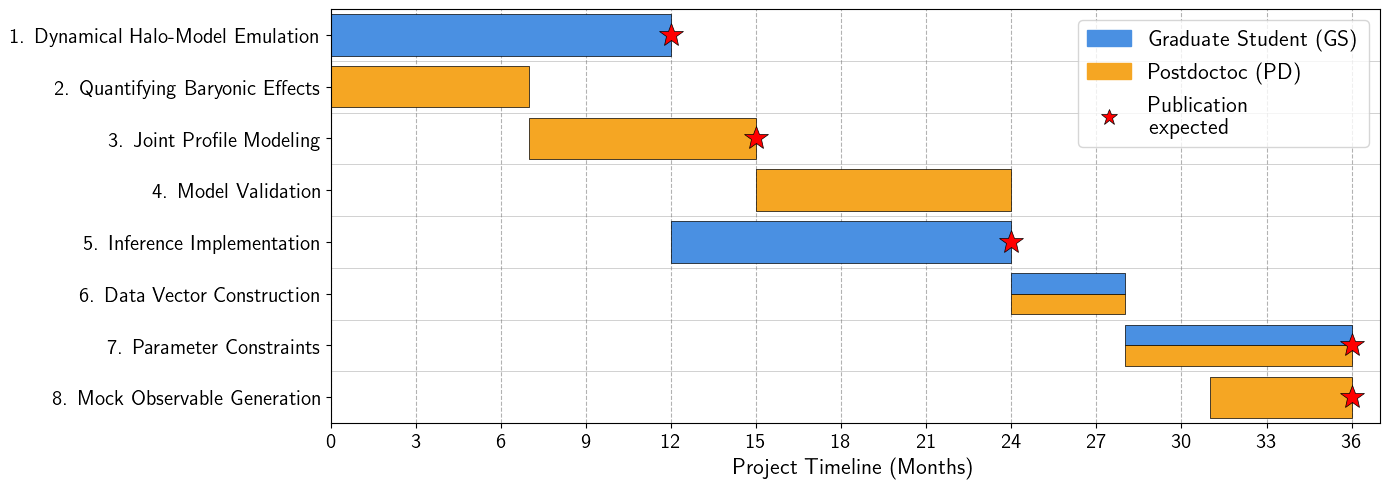

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.lines import Line2D
# change the font to something fancy:
# plt.style.use('seaborn-white')
plt.style.use('default')
plt.rc('text', usetex=True)
# plt.style.use('bmh')
# plt.style.use('ggplot')

# --- Data Setup ---
# Create a DataFrame from the project timeline
data = {
    'Task': [
        "1. Dynamical Halo-Model Emulation",
        "2. Quantifying Baryonic Effects",
        "3. Joint Profile Modeling",
        "4. Model Validation",
        "5. Inference Implementation",
        "6. Data Vector Construction",
        "7. Parameter Constraints",
        "8. Mock Observable Generation",
    ],
    'Person': ["Graduate Student (GS)",  "Postdoctoc (PD)", "Postdoctoc (PD)", "Postdoctoc (PD)", "Graduate Student (GS)", "Graduate Student (GS) & Postdoctoc (PD)", "Graduate Student (GS) & Postdoctoc (PD)", "Postdoctoc (PD)"],
    'Start_String': [
        "Year 1, Month 1", "Year 1, Month 1", "Year 1, Month 8",
        "Year 2, Month 4", "Year 2, Month 1", "Year 3, Month 1", "Year 3, Month 5", "Year 3, Month 8"
    ],
    'Duration_Days': [360, 210, 240, 270, 360, 120, 240, 150]
}
df = pd.DataFrame(data)

# --- Data Processing ---
# A helper function to convert 'Year X, Month Y' into days from project start
def convert_to_days(date_str):
    parts = date_str.replace(',', '').split()
    year = int(parts[1])
    month = int(parts[3])
    # Assuming 30 days per month for consistent plotting
    return ((year - 1) * 12 + (month - 1)) * 30

df['Start_Day'] = df['Start_String'].apply(convert_to_days)
# --- Plotting ---
# Change 1: UPostdoctoc (PD)ated figsize
fig, ax = plt.subplots(figsize=(14, 5))

# Define colors for each student
colors = {'Graduate Student (GS)': '#4A90E2', 'Postdoctoc (PD)': '#F5A623'}

# Plot each task
for idx, task in df.iterrows():
    y_pos = idx
    start = task['Start_Day']
    duration = task['Duration_Days']
    person = task['Person']

    if person == "Graduate Student (GS) & Postdoctoc (PD)":
        ax.broken_barh([(start, duration)], (y_pos - 0.4, 0.4), facecolors=colors['Graduate Student (GS)'], edgecolor='black', linewidth=0.5)
        ax.broken_barh([(start, duration)], (y_pos + 0.0, 0.4), facecolors=colors['Postdoctoc (PD)'], edgecolor='black', linewidth=0.5)
    else:
        ax.broken_barh([(start, duration)], (y_pos - 0.4, 0.8), facecolors=colors[person], edgecolor='black', linewidth=0.5)

# --- Add star markers ---
# x_months = [12, 15, 24, 36, 36]
# y_positions = [7, 4, 2, 2, 1, 0]

x_months = [12, 15, 24, 36, 36]
y_positions = [0, 2, 4, 6, 7]


# Convert months to days for x-coordinates
x_days = [m * 30 for m in x_months]

# Plot stars (using min length to handle mismatch)
for x, y in zip(x_days, y_positions):
    ax.plot(x, y, marker='*', color='red', markersize=18, markeredgecolor='black', markeredgewidth=0.5, zorder=10, label='Publication' + '\n' + 'Expected')

# --- Formatting ---
# Y-axis formatting
ax.set_ylim(-0.5, len(df) - 0.5)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['Task'], fontsize=15)
# Change 2: Ensure Task 1 is at the top
ax.invert_yaxis()

# X-axis formatting
ax.set_xlabel('Project Timeline (Months)', fontsize=16)
months = np.arange(0, 37, 3) # Ticks every 3 months
ax.set_xticks(months * 30)
ax.set_xticklabels(months, fontsize=15)
ax.set_xlim(0, 37 * 30)

# Change 3: Add thin horizontal lines for each task
ax.set_axisbelow(True) # Ensure grid lines are behind bars
ax.grid(axis='x', linestyle='--', color='gray', alpha=0.6)
ax.hlines(np.arange(len(df)) + 0.5, *ax.get_xlim(), color='gray', linewidth=0.5, alpha=0.5)


#ax.set_title('3-Year Research Project Graduate Student (GS)ntt Chart', fontsize=16, pad=20)

# Change 4: Place legend inside the plot in the upper right
patches = [
    mpatches.Patch(color=colors['Graduate Student (GS)'], label='Graduate Student (GS)'),
    mpatches.Patch(color=colors['Postdoctoc (PD)'], label='Postdoctoc (PD)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12, 
           markeredgecolor='black', markeredgewidth=0.5, label='Publication' + '\n' +  'expected')
]
ax.legend(handles=patches, loc='upper right', fontsize=16)

# Clean up layout
plt.tight_layout()

# Save and show the plot
plt.savefig("cosmology_gantt_chart.pdf", dpi=300)
plt.show()


